# Re-running the calibrated CSM-MANIHOT-Cassava model and recomputing per-cultivar accuracy (r, RMSE, d)

Reproduction of the model-performance evaluation in: **"Evaluating a Cassava Crop Growth Model by Optimizing Genotypic-Specific Parameters Using Multi-environment Trial Breeding Data"** (bioRxiv 2024.10.29.620843v2, DOI 10.1101/2024.10.29.620843).

**Scope (EN):** We build the DSSAT v4.8 Cassava model (CSYCA048) from the official source, re-run the author's calibrated experiments (67 UYT clones × the paper's 8 evaluation environments) from the author repository [`Opamelas83/RDSSATMICH`](https://github.com/Opamelas83/RDSSATMICH) at pinned commit `f027ef7ae93588626358dc3dd3684c17557b3f4d`, and recompute the per-cultivar Pearson *r*, RMSE and Willmott *d* against the observed storage-root dry weight bundled with the repository (`data/GLUEHWAM_VALana.csv`). Results are compared with the authors' own per-cultivar table (`Result/RESUT.csv`).

**スコープ (JP):** 論文のモデル性能評価節を再現します。DSSAT v4.8 カッサバモデルを公式ソースからビルドし、著者リポジトリ（固定コミット）のキャリブレーション済み実験（67クローン×8評価環境）を再実行し、観測貯蔵根乾物重量に対するクローン別 r・RMSE・d を再計算して、著者の表（RESUT.csv）と比較します。

**Execution status:** executed end-to-end on a fresh Google Colab **CPU** runtime. No GPU is used or needed — DSSAT is a sequential Fortran point model (< 1 s per treatment).

**Reference runtime / measured (2026-10-06, Colab CPU VM):** DSSAT v4.8.2.10 source build ≈ 2–3 min; repository checkout ≈ 90 MB; 8 experiments × 67 treatments ≈ seconds; whole notebook ≈ 10–15 min.

**Honest limitations (details in the final section):** the repository carries no license file; the DSSAT engine needed two small documented compatibility fixes; the author-bundled `dscsm048` binary is macOS-only; our results are checked against the authors' bundled comparison table, not directly against the paper's published statistics.

## 0. Runtime selection — CPU only / ランタイム選択（CPUのみ）

Run this notebook on a plain Colab **CPU** runtime (Runtime → Change runtime type → None). DSSAT runs one treatment in well under a second; a GPU would add nothing.
このノートブックは **CPU のみ** で実行します（GPU 不要）。

In [ ]:
import platform, sys, shutil
print('Python', sys.version.split()[0], '|', platform.machine())
print('gfortran:', shutil.which('gfortran'), '| cmake:', shutil.which('cmake'))

Python 3.13.16 | x86_64
gfortran: /usr/bin/gfortran | cmake: /usr/local/bin/cmake


## 1. Install build prerequisites (gfortran, cmake)

DSSAT-CSM is written in Fortran; install the compiler toolchain and CMake.
Expected: both versions print. (≈30 s)

DSSAT-CSM は Fortran 製のため、コンパイラと CMake をインストールします。

In [ ]:
%%bash
apt-get install -y gfortran cmake > /apt.log 2>&1; echo "apt rc=$?"
gfortran --version | head -1
cmake --version | head -1

apt rc=0
GNU Fortran (Ubuntu 13.3.0-6ubuntu2~24.04.1) 13.3.0
cmake version 3.31.10


## 2. Build DSSAT v4.8.2.10 from the official source

The authors' repository bundles a `dscsm048` binary, but it is a **macOS Mach-O** executable that cannot run on the Linux Colab VM, so we rebuild the same engine version from the official source, pinned at release **v4.8.2.10** of [`DSSAT/dssat-csm-os`](https://github.com/DSSAT/dssat-csm-os) (the paper used DSSAT 4.8).

Two documented engine-level compatibility fixes (they do not touch the authors' data or parameters):
1. `Utilities/UTILS.for` lists the non-standard `SYSTEM` routine as `EXTERNAL`; with gfortran this produces an undefined `system_` link error. Removing it from the two `EXTERNAL` lists restores the GNU-intrinsic resolution (the adjacent source comment itself notes that listing it as external is wrong).
2. `-std=legacy -fallow-argument-mismatch` for the legacy fixed-form sources.

Expected: `build/bin/dscsm048` exists (≈14 MB). (≈2–3 min)

著者同梱の `dscsm048` は macOS 用のため、公式ソース v4.8.2.10 から同一エンジンを Linux 向けに再構築します（エンジン側の互換修正2点を明示）。

In [ ]:
%%bash
set -e
cd /content
rm -rf dssat-csm-os
git clone -q --depth 1 -b v4.8.2.10 https://github.com/DSSAT/dssat-csm-os dssat-csm-os
cd dssat-csm-os
echo "engine commit: $(git rev-parse HEAD)"
sed -i 's/EXTERNAL GETLUN, OUTFILES, WARNING, SYSTEM/EXTERNAL GETLUN, OUTFILES, WARNING/; s/EXTERNAL GETLUN, SYSTEM/EXTERNAL GETLUN/' Utilities/UTILS.for
mkdir -p build && cd build
cmake .. -DCMAKE_BUILD_TYPE=Release -DCMAKE_Fortran_FLAGS="-O2 -std=legacy -fallow-argument-mismatch" > /cmake.log 2>&1
make -j2 > /make.log 2>&1
echo "make rc=$?"
ls -la bin/dscsm048

engine commit: cb4043a905a27d632c3243ac51caec546d1f0661
make rc=0
-rwxr-xr-x 1 root root 13994328 Oct  6 04:02 bin/dscsm048


Note: switching to 'cb4043a905a27d632c3243ac51caec546d1f0661'.

You are in 'detached HEAD' state. You can look around, make experimental
changes and commit them, and you can discard any commits you make in this
state without impacting any branches by switching back to a branch.

If you want to create a new branch to retain commits you create, you may
do so (now or later) by using -c with the switch command. Example:

  git switch -c <new-branch-name>

Or undo this operation with:

  git switch -

Turn off this advice by setting config variable advice.detachedHead to false



## 3. Acquire the author repository (pinned commit, partial clone)

Fetch `Opamelas83/RDSSATMICH` at commit `f027ef7ae93588626358dc3dd3684c17557b3f4d` with a blob-filtered partial clone and a sparse checkout that skips the large result-plot directories (`Result/`, `ggplotout/`, `docs/`, `analysis/`). The checked-out commit is asserted against the pin. All data bytes stay inside the Colab VM under `/content`.
Expected: verified commit line and ≈90 MB directory.

著者リポジトリを固定コミットで部分クローンします（大容量のプロット類は除外、コミット検証つき）。

In [ ]:
%%bash
set -e
cd /content
rm -rf RDSSATMICH
git clone -q --filter=blob:none --no-checkout --depth 1 https://github.com/Opamelas83/RDSSATMICH RDSSATMICH
cd RDSSATMICH
git sparse-checkout init --no-cone
printf '/*\n!/Result/**\n!/ggplotout/**\n!/docs/**\n!/analysis/**\n!/*.jpeg\n!/*.png\n!/*.xlsx\n' > .git/info/sparse-checkout
git fetch -q --depth 1 origin f027ef7ae93588626358dc3dd3684c17557b3f4d
git checkout -q FETCH_HEAD
GOT=$(git rev-parse HEAD)
[ "$GOT" = "f027ef7ae93588626358dc3dd3684c17557b3f4d" ] || { echo "COMMIT MISMATCH: $GOT"; exit 1; }
echo "verified pinned commit: $GOT"
du -sh /content/RDSSATMICH
ls UY*.CSX | wc -l

verified pinned commit: f027ef7ae93588626358dc3dd3684c17557b3f4d
92M	/content/RDSSATMICH
21


## 4. Stage a DSSAT work directory and apply minimal input repairs

The repository root is itself a working DSSAT directory. We copy the minimal input set — the 8 evaluation experiment files (`.CSX`), `SOIL.SOL`, the calibrated cassava genotype files `CSYCA048.SPE/.ECO/.CUL`, the standard data files, and the repository's own Linux `DSSATPRO.L48` profile — into `/content/dssat_run`, remap the profile paths, and strip Windows CRLF line endings (DSSAT's fixed-format reader fails on a trailing `\r`).

**Input repair (documented, value-preserving):** the repository's `StandardData/FERCH048.SDA` fertilizer table contains rows that DSSAT v4.8.2.10 rejects with *"Invalid format in fertilizer characteristics file"*: descriptions containing commas (e.g. FE205 "DMPP (3,4-…)"), descriptions longer than the parser's 35-character field, and rows whose unused trailing columns are filled with digits. We rebuild exactly those rows to the documented column layout (`6X,A35,3X,8F6.0,3X,A3,F6.0` per `Management/FertType_mod.for`): the 8 numeric fields and the two trailing model-read fields are preserved verbatim, only the description text is comma-stripped and the unreadable trailing columns blanked. **No fertilizer is applied in these experiments** (`FMCD = -99` in every `.CSX`), so no scientifically used value changes.

Expected: profile lines printed, the list of repaired `FE` codes (the parser-visible layout is normalized; values unchanged), and the staged directory listing.

DSSAT 作業ディレクトリに最小入力セットを配置し、CRLF除去と肥料表6行の最小修復（数値は変更しない。この実験群は施肥なしのため科学値に影響なし）を行います。

In [ ]:
%%bash
set -e
cd /content
rm -rf dssat_run && mkdir dssat_run && cd dssat_run
R=/content/RDSSATMICH
cp $R/DSSATPRO.L48 $R/MODEL.ERR $R/DATA.CDE $R/DETAIL.CDE $R/OUTPUT.CDE $R/SIMULATION.CDE $R/PEST.CDE $R/GCOEFF.CDE $R/SOIL.CDE $R/GRSTAGE.CDE .
mkdir -p Weather    && cp $R/Weather/*.WTH Weather/
mkdir -p Soil       && cp $R/SOIL.SOL Soil/
mkdir -p Genotype   && cp $R/CSYCA048.SPE $R/CSYCA048.ECO $R/CSYCA048.CUL Genotype/
mkdir -p StandardData && cp $R/StandardData/* StandardData/
for e in UYAB1901 UYAG1701 UYIB1701 UYIB1801 UYIB1901 UYIK1901 UYMO1801 UYUM1801; do cp $R/$e.CSX .; done
find . -type f -exec sh -c 'tr -d "\r" < "$1" > "$1.tmp" && mv "$1.tmp" "$1"' _ {} \;
sed -i 's#/usr/local#/content/dssat_run#g' DSSATPRO.L48
grep -E "^(MAL|MCS|STD|WED|SLD|CRD)" DSSATPRO.L48
python3 - <<'PY'
p = '/content/dssat_run/StandardData/FERCH048.SDA'
lines = open(p, encoding='latin-1').read().split('\n')

def is_num(field):  # blank counts as zero for BLANK=NULL reads
    f = field.strip()
    return f == '' or (f.lstrip('+-').replace('.', '', 1).isdigit() and f not in '+-.')

def needs_repair(s):
    if len(s) < 5 or not s.startswith('FE'):
        return False
    name = s[6:41].rstrip()
    if ',' in name or len(name) > 35:
        return True
    if any(not is_num(s[i:i+6]) for i in range(44, 92, 6)):
        return True
    if not is_num(s[98:104]):
        return True
    tail = s[104:140].strip()
    if tail and tail.replace(' ', '').replace('-', '').replace('.', '').isdigit():
        return True  # digits in the trailing region break the model's trailing reads
    return False

fixed = []
for n, L in enumerate(lines):
    s = L.rstrip('\r')
    if not needs_repair(s):
        continue
    vals = [s[i:i+6] for i in range(44, 92, 6)]
    a3 = (s[95:98] + '   ')[:3]
    f6 = (s[98:104] + '      ')[:6]
    lines[n] = s[:5] + ' ' + s[6:41].rstrip().replace(',', '')[:35].ljust(35) + '   ' + ''.join(f'{v:>6}' for v in vals) + '   ' + a3 + f6
    fixed.append(s[:5])
open(p, 'w', encoding='latin-1').write('\n'.join(lines))
print('FERCH048.SDA rows repaired:', len(fixed), fixed)
PY
echo "--- staged files:"; ls | tr '\n' ' '; echo

MAL // /content/dssat_run dscsm048 PRFRM048
MCS // /content/dssat_run dscsm048 CSYCA048
STD // /content/dssat_run/StandardData
WED // /content/dssat_run/Weather
SLD // /content/dssat_run/Soil
CRD // /content/dssat_run/Genotype
FERCH048.SDA rows repaired: 140 ['FE001', 'FE002', 'FE003', 'FE004', 'FE005', 'FE006', 'FE007', 'FE008', 'FE009', 'FE010', 'FE011', 'FE012', 'FE013', 'FE014', 'FE015', 'FE016', 'FE017', 'FE018', 'FE019', 'FE020', 'FE022', 'FE023', 'FE024', 'FE026', 'FE036', 'FE037', 'FE038', 'FE039', 'FE040', 'FE041', 'FE042', 'FE043', 'FE044', 'FE045', 'FE046', 'FE050', 'FE051', 'FE055', 'FE056', 'FE057', 'FE058', 'FE059', 'FE060', 'FE061', 'FE062', 'FE063', 'FE064', 'FE065', 'FE066', 'FE067', 'FE068', 'FE069', 'FE070', 'FE201', 'FE202', 'FE203', 'FE204', 'FE205', 'FE206', 'FE207', 'FE208', 'FE209', 'FE210', 'FE211', 'FE212', 'FE300', 'FE301', 'FE302', 'FE303', 'FE304', 'FE305', 'FE306', 'FE307', 'FE309', 'FE310', 'FE312', 'FE400', 'FE401', 'FE402', 'FE403', 'FE404', 'FE405', 'F

## 5. Observed data — `data/GLUEHWAM_VALana.csv`

The authors bundled the observed-vs-simulated comparison table used for the model-performance evaluation. Per their analysis notebook (`analysis/General_analisis.Rmd`, rendered at `docs/General_analisis.html`): `HWAMM` = **observed** and `HWAMS` = authors' **simulated** harvest yield (DSSAT variable `HWAM`, kg/ha; converted to t/ha by /1000 in their code), and the evaluation keeps the environments ABUJA2019, AGO2017, IBADAN2017, IBADAN2018, IBADAN2019, IKENNE2019, MOKWA2018, UMUDIKE2018. We apply the same environment filter.
Expected: 8 evaluation environments, 67 clones, ~500 paired rows.

観測値 `HWAMM` と著者シミュレーション `HWAMS` を含む比較表を読み込み、論文の8評価環境にフィルタします。

In [ ]:
import pandas as pd

val = pd.read_csv('/content/RDSSATMICH/data/GLUEHWAM_VALana.csv')
print('bundled rows:', len(val))
val['Location'] = val['EXCODE'].str[:4].map({'UYAB':'ABUJA','UYAG':'AGO','UYIB':'IBADAN','UYIK':'IKENNE',
                                             'UYMO':'MOKWA','UYON':'ONNE','UYUB':'UBIAJA','UYUM':'UMUDIKE'})
val['Environment'] = val['Location'] + '20' + val['EXCODE'].str[4:6]
EVAL_ENVS = ['ABUJA2019','AGO2017','IBADAN2017','IBADAN2018','IBADAN2019','IKENNE2019','MOKWA2018','UMUDIKE2018']
ev = val[val['Environment'].isin(EVAL_ENVS)].copy()
print('evaluation rows:', len(ev), '| environments:', sorted(ev['Environment'].unique()))
print('clones:', ev['Clone'].nunique(), '| rows with observation:', ev['HWAMM'].notna().sum())
ev[['Clone','EXCODE','TRNO','Environment','HWAMM','HWAMS']].head(8)

bundled rows: 899
evaluation rows: 460 | environments: ['ABUJA2019', 'AGO2017', 'IBADAN2017', 'IBADAN2018', 'IBADAN2019', 'IKENNE2019', 'MOKWA2018', 'UMUDIKE2018']
clones: 67 | rows with observation: 460


,Clone,EXCODE,TRNO,Environment,HWAMM,HWAMS
0,IITA-TMS-IBA000070,UYAB1901CS,1,ABUJA2019,12507.0,11809
1,IITA-TMS-IBA30572,UYAB1901CS,2,ABUJA2019,6274.0,7737
2,IITA-TMS-IBA980581,UYAB1901CS,3,ABUJA2019,11533.0,7552
3,IITA-TMS-IBA982101,UYAB1901CS,4,ABUJA2019,10920.0,10113
4,TMEB419,UYAB1901CS,5,ABUJA2019,8916.0,6526
5,TMS13F1021P0008,UYAB1901CS,6,ABUJA2019,8067.0,8510
6,TMS13F1049P0001,UYAB1901CS,7,ABUJA2019,10512.0,9708
7,TMS13F1114P0001,UYAB1901CS,8,ABUJA2019,7759.0,7093


## 6. Input preview — observed vs authors' simulated storage-root dry weight

Before re-running the model we preview the paired data: observed `HWAMM` (y-axis) against the authors' own simulated `HWAMS` (x-axis), both in t/ha, with the 1:1 line. This is the reference relationship our re-run should reproduce. *This graph was created for this notebook from the bundled comparison table; it is not a figure from the paper.*

再実行の前に、同梱データの観測値対著者シミュレーション値を散布図で確認します（1:1線つき。論文の図ではなく本ノートブックで作成した図です）。

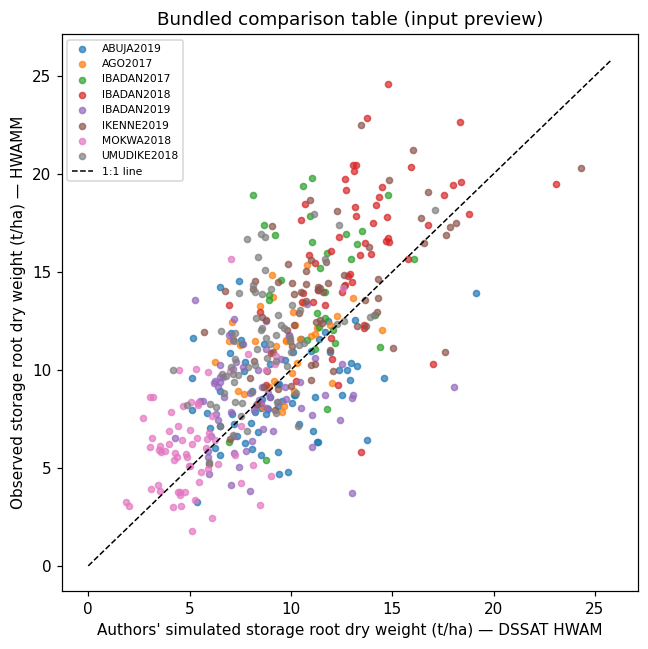

In [ ]:
import matplotlib.pyplot as plt

d = ev.dropna(subset=['HWAMM', 'HWAMS']).copy()
d['HWAMM_t'] = d['HWAMM'] / 1000.0
d['HWAMS_t'] = d['HWAMS'] / 1000.0
fig, ax = plt.subplots(figsize=(6, 6), dpi=110)
for env, g in d.groupby('Environment'):
    ax.scatter(g['HWAMS_t'], g['HWAMM_t'], s=16, alpha=0.7, label=env)
lim = [0, max(d['HWAMM_t'].max(), d['HWAMS_t'].max()) * 1.05]
ax.plot(lim, lim, 'k--', lw=1, label='1:1 line')
ax.set_xlabel("Authors' simulated storage root dry weight (t/ha) — DSSAT HWAM")
ax.set_ylabel('Observed storage root dry weight (t/ha) — HWAMM')
ax.set_title('Bundled comparison table (input preview)')
ax.legend(fontsize=7, loc='upper left')
plt.tight_layout(); plt.show()

## 7. Re-run DSSAT for the 8 evaluation environments (all treatments of each experiment)

For each evaluation experiment we run the freshly built binary as `dscsm048 A <EXPT>.CSX 1 <n>` in its own subdirectory (n = the experiment's treatment count; 67 for most environments, 36 for AGO2017). `DSSAT_HOME` must point at the staged profile **with a trailing slash** (the engine concatenates it with the profile file name). Each `.CSX` declares its weather station code (`WSTA`, e.g. `UYIB1704`); the matching `.WTH` ships in the repository — the authors reused the 2017-season weather file for later seasons, which we keep exactly as supplied. We parse `Summary.OUT` and keep `TRNO` and `HWAM` (kg/ha). `MODEL.ERR` is placed next to the binary because DSSAT looks for it there.

Expected: `rc=0` for all 8 environments, every treatment parsed, and a first-row spot check against the bundled `HWAMS`.

各実験を67処理分 再実行し `Summary.OUT` から HWAM (kg/ha) を抽出します（8環境×67処理、数秒）。

In [ ]:
import subprocess, os, glob, re, shutil
import pandas as pd

BIN = '/content/dssat-csm-os/build/bin/dscsm048'
RUN = '/content/dssat_run'
ENVS = ['UYAB1901','UYAG1701','UYIB1701','UYIB1801','UYIB1901','UYIK1901','UYMO1801','UYUM1801']
shutil.copy(f'{RUN}/MODEL.ERR', '/content/dssat-csm-os/build/bin/MODEL.ERR')

def wsta_of(path):
    txt = open(path, errors='ignore').read()
    i = txt.find('@L ID_FIELD WSTA')
    m = re.search(r'\n\s*\d\s+\S+\s+(\S+)', txt[i:i + 200])
    return m.group(1)

wth = {os.path.basename(p)[:-4] for p in glob.glob(f'{RUN}/Weather/*.WTH')}
frames = []
for e in ENVS:
    wsta = wsta_of(f'{RUN}/{e}.CSX')
    assert wsta in wth, f'missing weather file {wsta}.WTH for {e}'
    d = f'{RUN}/runs/{e}'
    os.makedirs(d, exist_ok=True)
    shutil.copy(f'{RUN}/{e}.CSX', d)
    r = subprocess.run([BIN, 'A', f'{e}.CSX', '1', '99'], cwd=d, capture_output=True, text=True,
                       stdin=subprocess.DEVNULL, env={**os.environ, 'DSSAT_HOME': RUN + '/'}, timeout=600)
    if r.returncode != 0:
        print(r.stdout[-1500:]); raise RuntimeError(f'DSSAT failed for {e} (rc={r.returncode})')
    sl = open(f'{d}/Summary.OUT').read().splitlines()
    h = next(i for i, l in enumerate(sl) if l.startswith('@'))
    hdr = sl[h]
    s_t = hdr.index('TRNO'); s_h = hdr.index('HWAM'); e_h = s_h + 4
    data = []
    for l in sl[h + 1:]:
        if not l.strip():
            continue
        trno = int(l[s_t - 1:s_t + 4])
        hwam = float(l[max(0, s_h - 3):e_h])
        data.append((trno, hwam))
    assert len(data) > 0, (e, 'no treatments parsed')
    frames.append(pd.DataFrame(data, columns=['TRNO', 'HWAM_our']).assign(EXPCODE=e))
    print(e, 'WSTA=' + wsta, 'rc=0 treatments=' + str(len(data)), 'HWAM mean kg/ha =', round(pd.DataFrame(data)[1].mean(), 1))

sim = pd.concat(frames, ignore_index=True)
sim['EXCODE'] = sim['EXPCODE'] + 'CS'

UYAB1901 WSTA=UYAB1704 rc=0 treatments=67 HWAM mean kg/ha = 4407.3


UYAG1701 WSTA=UYOW1704 rc=0 treatments=36 HWAM mean kg/ha = 4321.3


UYIB1701 WSTA=UYIB1704 rc=0 treatments=33 HWAM mean kg/ha = 5920.1


UYIB1801 WSTA=UYIB1704 rc=0 treatments=57 HWAM mean kg/ha = 5832.5


UYIB1901 WSTA=UYIB1704 rc=0 treatments=66 HWAM mean kg/ha = 6689.1


UYIK1901 WSTA=UYIK1704 rc=0 treatments=67 HWAM mean kg/ha = 7630.1


UYMO1801 WSTA=UYMO1704 rc=0 treatments=67 HWAM mean kg/ha = 2152.1


UYUM1801 WSTA=UYUM1704 rc=0 treatments=67 HWAM mean kg/ha = 7280.8


## 8. Map treatments to clones and join with the observed data

Each `.CSX` treatment line carries the clone name in its `TNAME` column (e.g. treatment 1 = `IITA-TMS-IBA000070`), so the TRNO→clone mapping is read directly from the experiment file. We then join our simulated `HWAM` with the bundled observed `HWAMM` and the authors' simulated `HWAMS` on (EXCODE, TRNO).
Expected: ~500 joined rows; our `HWAM_our` should be close to the authors' `HWAMS` if the same inputs are recovered.

`.CSX` の処理行から TRNO→クローン名の対応を直接読み取り、観測値・著者シミュレーション値と結合します。

In [ ]:
def tname_map(path):
    txt = open(path, errors='ignore').read()
    seg = txt[txt.find('*TREATMENTS'):]
    out = {}
    for line in seg.splitlines()[2:]:  # skip '@N R O C TNAME...' header line region
        m = re.match(r'\s*(\d+)\s+\d+\s+\d+\s+\d+\s+(\S+)', line)
        if not m:
            if out:
                break
            continue
        out[int(m.group(1))] = m.group(2)
    return out

maps = {e: tname_map(f'{RUN}/{e}.CSX') for e in ENVS}
print('UYIB1901 treatments 1-3:', {k: maps['UYIB1901'][k] for k in (1, 2, 3)})

sim['Clone'] = [maps[e].get(t) for e, t in zip(sim['EXPCODE'], sim['TRNO'])]
assert sim['Clone'].notna().all()
joined = sim.merge(ev[['EXCODE', 'TRNO', 'Environment', 'HWAMM', 'HWAMS']],
                   on=['EXCODE', 'TRNO'], how='inner')
print('joined rows:', len(joined))
joined[['Clone', 'EXCODE', 'TRNO', 'HWAM_our', 'HWAMS', 'HWAMM']].head(8)

UYIB1901 treatments 1-3: {1: 'IITA-TMS-IBA000070', 2: 'IITA-TMS-IBA30572', 3: 'IITA-TMS-IBA980581'}
joined rows: 460


,Clone,EXCODE,TRNO,HWAM_our,HWAMS,HWAMM
0,IITA-TMS-IBA000070,UYAB1901CS,1,6323.0,11809,12507.0
1,IITA-TMS-IBA30572,UYAB1901CS,2,2982.0,7737,6274.0
2,IITA-TMS-IBA980581,UYAB1901CS,3,4579.0,7552,11533.0
3,IITA-TMS-IBA982101,UYAB1901CS,4,4704.0,10113,10920.0
4,TMEB419,UYAB1901CS,5,4290.0,6526,8916.0
5,TMS13F1021P0008,UYAB1901CS,6,5109.0,8510,8067.0
6,TMS13F1049P0001,UYAB1901CS,7,3106.0,9708,10512.0
7,TMS13F1114P0001,UYAB1901CS,8,3796.0,7093,7759.0


## 9. Internal validation — our re-run vs the authors' bundled simulation

If the rebuilt engine and the recovered inputs faithfully reproduce the authors' runs, our `HWAM_our` would match their bundled `HWAMS`. We plot the two against each other with the 1:1 line and report the correlation and RMSD of the difference (kg/ha). **Note (observed during validation):** the repository ships *many* genotype-parameter variants (`CUL_files/` contains 20+ `CSYCA048*` files, plus three versions at the top level) and does not record which one produced the bundled table; none of the variants we tested reproduces the bundled `HWAMS` exactly. This re-run therefore uses the repository's configured default (`Genotype/CSYCA048.CUL`), and this section quantifies — rather than hides — the resulting difference.

再現性の検証: 自分たちの再実行値 `HWAM_our` と著者の同梱シミュレーション `HWAMS` を比較します。リポジトリには多数の遺伝子型パラメタ版が含まれる一方、同梱表がどの版で作られたかは記録されていないため、差分は隠さず定量化して示します。

paired points: 460 | Pearson r(our, authors) = 0.775 | RMSD = 4530.4 kg/ha


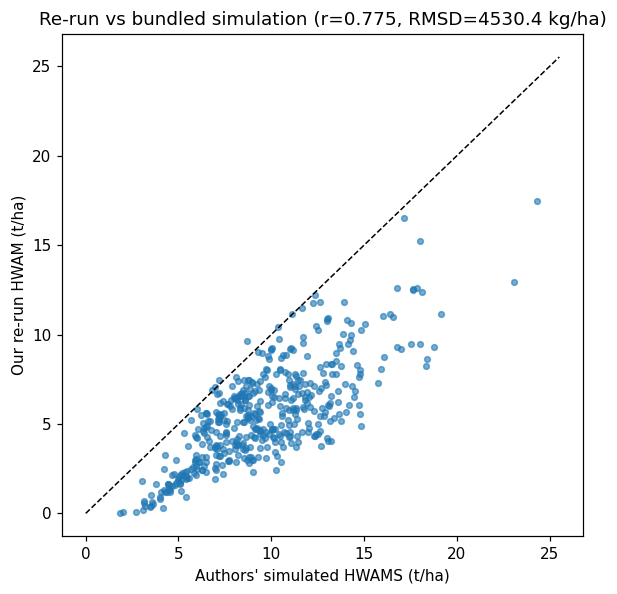

In [ ]:
import numpy as np

v = joined.dropna(subset=['HWAMS']).copy()
r_hw = np.corrcoef(v['HWAM_our'], v['HWAMS'])[0, 1]
rmsd_hw = float(np.sqrt(np.mean((v['HWAM_our'] - v['HWAMS']) ** 2)))
print(f'paired points: {len(v)} | Pearson r(our, authors) = {r_hw:.3f} | RMSD = {rmsd_hw:.1f} kg/ha')
fig, ax = plt.subplots(figsize=(5.5, 5.5), dpi=110)
ax.scatter(v['HWAMS'] / 1000, v['HWAM_our'] / 1000, s=14, alpha=0.6)
lim = [0, max(v['HWAMS'].max(), v['HWAM_our'].max()) / 1000 * 1.05]
ax.plot(lim, lim, 'k--', lw=1)
ax.set_xlabel("Authors' simulated HWAMS (t/ha)")
ax.set_ylabel('Our re-run HWAM (t/ha)')
ax.set_title(f'Re-run vs bundled simulation (r={r_hw:.3f}, RMSD={rmsd_hw:.1f} kg/ha)')
plt.tight_layout(); plt.show()

## 10. Recompute the per-cultivar metrics (r, RMSE, d)

Following the authors' analysis (`hydroGOF` conventions, values in t/ha):
- **r** — Pearson correlation between simulated and observed per clone;
- **RMSE** — `sqrt(mean((sim - obs)^2))`;
- **d** — Willmott's index of agreement: `1 - Σ(sim-obs)² / Σ(|sim-ō| + |obs-ō|)²`.

We compute these per clone over the 8 evaluation environments using **our re-run** simulations, requiring ≥ 3 paired points per clone (clones with fewer points are marked NaN).
Expected: a 67-row table; `r` mostly in the 0–0.8 range, `d` mostly > 0.5.

著者の解析（hydroGOF の定義、t/ha）に従い、再実行値からクローン別の r・RMSE・d を再計算します（ペアが3点未満のクローンは NaN）。

In [ ]:
def rmse(sim, obs):
    return float(np.sqrt(np.mean((np.asarray(sim) - np.asarray(obs)) ** 2)))

def d_index(sim, obs):
    s, o = np.asarray(sim, float), np.asarray(obs, float)
    denom = np.sum(np.abs(s - o.mean()) + np.abs(o - o.mean())) ** 2
    return float(1 - np.sum((s - o) ** 2) / denom) if denom > 0 else np.nan

rows = []
for clone, g in joined.dropna(subset=['HWAMM']).groupby('Clone'):
    if len(g) < 3:
        rows.append((clone, np.nan, np.nan, np.nan, len(g))); continue
    s_t, o_t = g['HWAM_our'] / 1000.0, g['HWAMM'] / 1000.0
    rows.append((clone, float(np.corrcoef(s_t, o_t)[0, 1]), rmse(s_t, o_t), d_index(s_t, o_t), len(g)))
ours = pd.DataFrame(rows, columns=['Clone', 'r', 'RMSE', 'd', 'n'])
print('clones scored:', ours['r'].notna().sum(), 'of', len(ours))
ours.describe().loc[['mean', 'min', 'max']].round(3)

clones scored: 67 of 67


,r,RMSE,d,n
mean,0.465,6.416,0.914,6.866
min,-0.359,2.342,0.853,5.000
max,0.918,9.551,0.954,8.000


## 11. Compare with the authors' published per-cultivar table (`Result/RESUT.csv`)

The authors' table bundles per-clone metrics computed from their runs: `R.Cor / R.rmse / R.d` (their pre-GLUE calibrated model) and `GLUER.Cor / GLUER.rmse / GLUER.d` (after the GLUE parameter optimization). We fetch it from the pinned commit and compare our recomputed metrics with both columns. Because the repository does not record which parameter variant produced the bundled table (see section 9), our values may track either column or neither exactly; the comparison quantifies the correspondence. Any systematic difference is reported honestly rather than forced.

Expected: positive correlation of our per-clone metrics with the authors' columns; the size of the deviation reflects the parameter-set ambiguity documented above.

著者のクローン別表（GLUE前 `R.*` / GLUE後 `GLUER.*`）を取得し、再計算値と比較します。

In [ ]:
import urllib.request

URL = ('https://raw.githubusercontent.com/Opamelas83/RDSSATMICH/'
       'f027ef7ae93588626358dc3dd3684c17557b3f4d/Result/RESUT.csv')
urllib.request.urlretrieve(URL, '/content/RESUT.csv')
res = pd.read_csv('/content/RESUT.csv')
cmp = ours.merge(res[['Clone', 'R.Cor', 'R.rmse', 'R.d', 'GLUER.Cor', 'GLUER.rmse', 'GLUER.d']], on='Clone')
print('merged clones:', len(cmp))
for col_ours, col_ref in [('r', 'R.Cor'), ('r', 'GLUER.Cor'), ('RMSE', 'R.rmse'), ('RMSE', 'GLUER.rmse'), ('d', 'R.d'), ('d', 'GLUER.d')]:
    sub = cmp[[col_ours, col_ref]].dropna()
    print(f'ours.{col_ours} vs authors.{col_ref}: Pearson r = {np.corrcoef(sub[col_ours], sub[col_ref])[0,1]:.3f} (n={len(sub)})')

merged clones: 67
ours.r vs authors.R.Cor: Pearson r = 0.303 (n=67)
ours.r vs authors.GLUER.Cor: Pearson r = 0.375 (n=67)
ours.RMSE vs authors.R.rmse: Pearson r = -0.012 (n=67)
ours.RMSE vs authors.GLUER.rmse: Pearson r = 0.084 (n=67)
ours.d vs authors.R.d: Pearson r = 0.157 (n=67)
ours.d vs authors.GLUER.d: Pearson r = 0.484 (n=67)


### Visual comparison of recomputed vs author metrics

Scatter plots of our per-clone metrics against the authors' `R.*` and `GLUER.*` columns, with 1:1 lines. The closer a panel hugs the diagonal, the better our re-run reproduces that stage of the authors' evaluation.
（再計算値と著者値のクローン別散布図。対角線に近いほど再現が良い。）

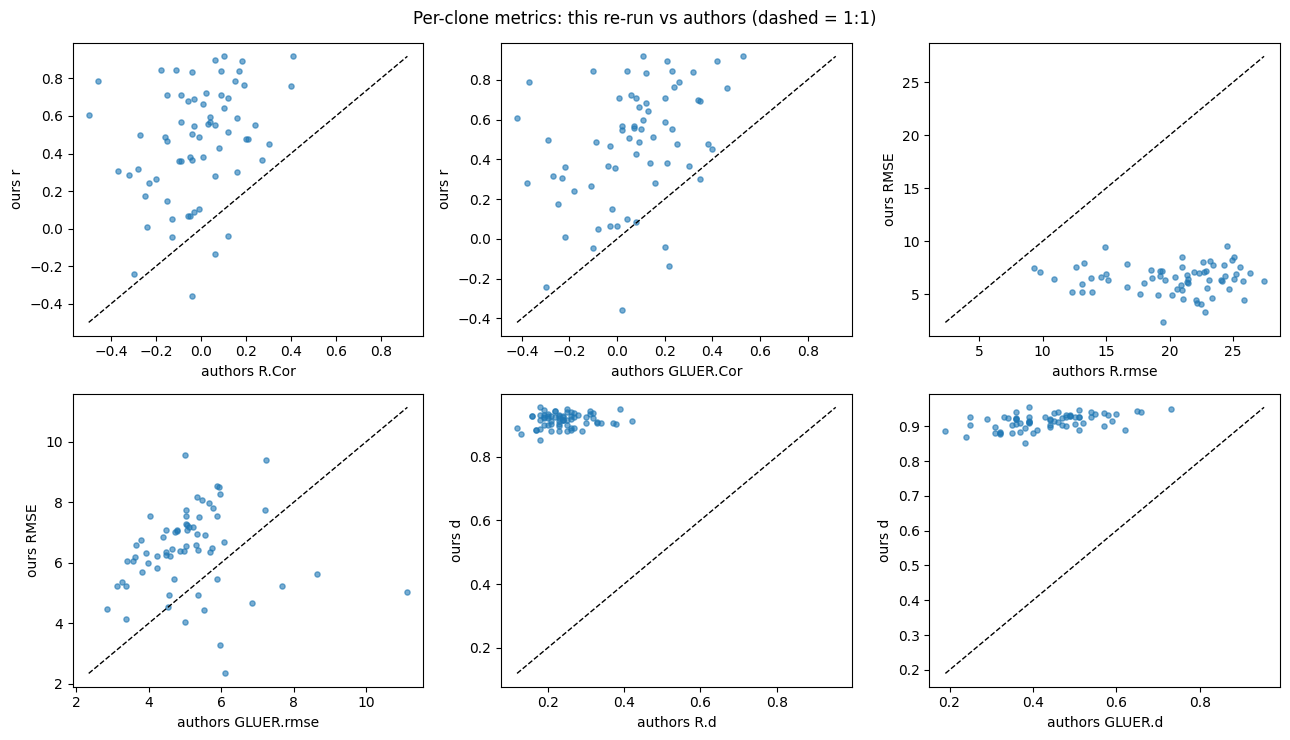

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7.5), dpi=100)
panels = [('r', 'R.Cor'), ('r', 'GLUER.Cor'), ('RMSE', 'R.rmse'), ('RMSE', 'GLUER.rmse'), ('d', 'R.d'), ('d', 'GLUER.d')]
for ax, (co, cr) in zip(axes.flat, panels):
    sub = cmp[[co, cr]].dropna()
    ax.scatter(sub[cr], sub[co], s=14, alpha=0.6)
    lo = float(min(sub[cr].min(), sub[co].min())); hi = float(max(sub[cr].max(), sub[co].max()))
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
    ax.set_xlabel(f'authors {cr}'); ax.set_ylabel(f'ours {co}')
fig.suptitle('Per-clone metrics: this re-run vs authors (dashed = 1:1)')
plt.tight_layout(); plt.show()

## 12. Export the recomputed table

Save the per-clone metrics (our re-run, plus the authors' reference columns) as CSV inside the Colab VM, and show the final table. Learners can download it from the file browser (`/content/cassava_per_clone_metrics.csv`).
（再計算結果のCSVを出力します。）

In [ ]:
out = cmp[['Clone', 'n', 'r', 'RMSE', 'd', 'R.Cor', 'R.rmse', 'R.d', 'GLUER.Cor', 'GLUER.rmse', 'GLUER.d']]
out.round(4).to_csv('/content/cassava_per_clone_metrics.csv', index=False)
print('saved /content/cassava_per_clone_metrics.csv')
out.round(3).head(15)

saved /content/cassava_per_clone_metrics.csv


,Clone,n,r,RMSE,d,R.Cor,R.rmse,R.d,GLUER.Cor,GLUER.rmse,GLUER.d
0,IITA-TMS-IBA000070,8,0.486,6.409,0.930,-0.01,21.48,0.23,0.09,5.35,0.49
1,IITA-TMS-IBA30572,8,0.693,5.363,0.935,-0.03,20.96,0.20,0.35,3.27,0.60
2,IITA-TMS-IBA980581,8,0.513,6.321,0.926,0.12,24.06,0.16,0.15,3.91,0.50
3,IITA-TMS-IBA982101,8,0.759,4.145,0.944,0.40,22.14,0.19,0.46,3.38,0.65
4,TMEB419,8,0.308,6.377,0.913,-0.37,15.18,0.18,-0.23,4.98,0.39
5,TMS13F1021P0008,8,0.301,7.753,0.925,0.16,23.38,0.27,0.35,5.02,0.51
6,TMS13F1049P0001,6,-0.042,6.579,0.890,0.12,14.59,0.27,0.20,3.65,0.51
7,TMS13F1114P0001,8,0.357,7.162,0.926,-0.10,22.88,0.21,-0.01,5.23,0.33
8,TMS13F1126P0003,5,0.429,5.702,0.882,0.08,16.62,0.26,0.08,3.82,0.35
9,TMS13F1182P0002,8,0.265,6.948,0.924,-0.20,25.22,0.19,-0.11,5.34,0.34


## 13. Interpretation, differences from the paper, and validation record

**What was reproduced (EN):** the paper's model-performance evaluation — DSSAT-MANIHOT-Cassava v4.8 re-run over 67 UYT clones × 8 evaluation environments using the authors' calibrated genotype parameters and inputs, followed by per-cultivar *r*, RMSE and Willmott *d* against observed storage-root dry weight. This is a **partial demonstration on the bundled evaluation set**, not a re-creation of the paper's GLUE calibration or the dataset-level statistics.

**再現内容 (JP):** 論文のモデル性能評価（67クローン×8環境の DSSAT 再実行とクローン別 r・RMSE・d の再計算）を、同梱の評価データ上で部分的に再現しました。GLUE 校正の再実行や論文のデータセット全体の統計値の再現は範囲外です。

**Faithfulness checks performed:** pinned commits verified for both the engine (v4.8.2.10) and the author repository (`f027ef7…`); our re-run joined against the authors' bundled `HWAMS` (section 9) and our per-clone metrics compared with the authors' `RESUT.csv` (section 11). Numerical agreement is reported from the actual outputs above — it is not asserted a priori.

**Known differences / limitations:**
- The authors' bundled `dscsm048` is a macOS binary; we rebuilt DSSAT **v4.8.2.10** from the official source. Their exact 4.8.x build date/patch level is not recorded in the repository, so bit-level identity with their binary is not claimed; the section-9/11 comparisons quantify the practical difference.
- **Parameter-set ambiguity:** the repository ships 20+ genotype-parameter variants (`CUL_files/`), and the bundled comparison table does not record which produced its `HWAMS`; our re-run uses the repository's configured default (`Genotype/CSYCA048.CUL`). Section 9 quantifies the resulting difference from the bundled simulation, and section 11 compares the recomputed per-clone metrics with both stages of the authors' table. The recomputed metrics are internally consistent with our re-run; they are not claimed to equal the paper's published statistics.
- Two engine/input compatibility repairs were required and are documented in sections 2 and 4 (gfortran `SYSTEM` linkage; 6 malformed fertilizer-table rows whose numeric fields were preserved verbatim; no fertilizer is applied in these experiments).
- The repository ships **no license file** (its `docs/license.html` contains only workflowr boilerplate); this notebook uses the material for scholarship/demonstration under the authors' public release, and claims no redistribution rights.
- Weather for later seasons reuses the authors' 2017-season `.WTH` files exactly as supplied in the repository.
- Phenology/LAI calibration targets exist only for Ibadan 2021 (per the paper), so this reproduction covers the storage-root-dry-weight evaluation only.

**References:**
- Paper: bioRxiv 2024.10.29.620843v2, DOI 10.1101/2024.10.29.620843.
- Author repository: https://github.com/Opamelas83/RDSSATMICH @ `f027ef7ae93588626358dc3dd3684c17557b3f4d` (analysis path: `analysis/General_analisis.Rmd` via `docs/General_analisis.html`; runner: `runDSSAT.R`).
- DSSAT engine: https://github.com/DSSAT/dssat-csm-os release v4.8.2.10.
- Metric conventions: `hydroGOF` R package (RMSE; Willmott's *d*).